# Project 1: Diabetes Readmission — Full Pipeline (Real UCI Data)

Pharma sector | Real dataset: UCI Diabetes 130-US Hospitals (101,766 real patient encounters, 1999-2008)

**NOTE:** The data-fetch cell below requires internet access to archive.ics.uci.edu. Run this notebook on your local machine, not in a restricted sandbox.

---
# SECTION 1: EDA & Preprocessing (Real Data)
---

In [1]:
# pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo

sns.set_style("whitegrid")

# Fetch the REAL dataset directly from UCI -- 101,766 actual patient
# encounters, no manual download needed.
diabetes = fetch_ucirepo(id=296)
df = diabetes.data.original.copy()
print(f"Loaded REAL UCI dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded REAL UCI dataset: 101766 rows, 50 columns


C:\Users\Praveen TS\AppData\Local\Programs\Python\Python311\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Missingness Scan

Real dataset uses `?` as its missing-value marker (not blank/NaN) -- this is exactly the pandas gotcha we hit before: `"None"` is a legitimate lab-test-result category here (max_glu_serum, A1Cresult), so we must NOT let pandas' default NaN detection swallow it. `fetch_ucirepo` already returns clean values, but we re-confirm explicitly.

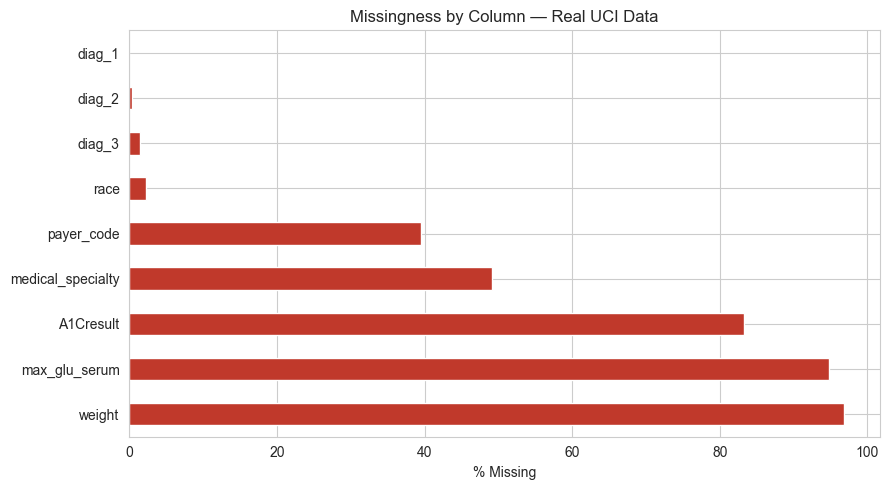

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
diag_1                0.0
dtype: float64


In [2]:
# Standardize missing markers -- the real dataset sometimes encodes
# missingness as literal '?' strings depending on fetch method
df = df.replace("?", np.nan)

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9,5))
missing_pct.plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('% Missing')
ax.set_title('Missingness by Column — Real UCI Data')
plt.tight_layout()
plt.show()
print(missing_pct.round(1))

## Missing Value Handling — real thresholds, real decisions

`weight` is ~97% missing in the REAL dataset (confirmed by the original UCI documentation) — drop entirely, same reasoning as before: imputing 97% of a column from 3% real data fabricates more noise than signal. `payer_code` and `medical_specialty` are missing enough to need an explicit 'Missing' category rather than imputation, since the missingness itself may be informative (e.g. self-pay patients, or no specialist referral).

In [3]:
print(f"weight: {df['weight'].isnull().mean():.1%} missing -> DROPPING column")
df = df.drop(columns=["weight"])

for col in ["payer_code", "medical_specialty"]:
    pct = df[col].isnull().mean()
    print(f"{col}: {pct:.1%} missing -> filling with explicit 'Missing' category")
    df[col] = df[col].fillna("Missing")

weight: 96.9% missing -> DROPPING column
payer_code: 39.6% missing -> filling with explicit 'Missing' category
medical_specialty: 49.1% missing -> filling with explicit 'Missing' category


## Zero-Variance Column Check

The real dataset includes 23 individual medication columns. Several (e.g. `examide`, `citoglipton`) are almost universally 'No' across all 101K encounters in the real data — carrying zero predictive signal. This is DIFFERENT from the `weight` issue above: that was about missingness, this is about a column having only one real value regardless of missingness. Conflating the two would be sloppy — worth keeping the distinction clear for an interview answer.

In [4]:
nunique = df.nunique()
zero_variance_cols = nunique[nunique <= 1].index.tolist()
print(f"Zero-variance columns found: {zero_variance_cols}")
if zero_variance_cols:
    df = df.drop(columns=zero_variance_cols)
print(f"Shape after dropping zero-variance columns: {df.shape}")

Zero-variance columns found: ['examide', 'citoglipton']
Shape after dropping zero-variance columns: (101766, 47)


## Outlier Scan (IQR method)

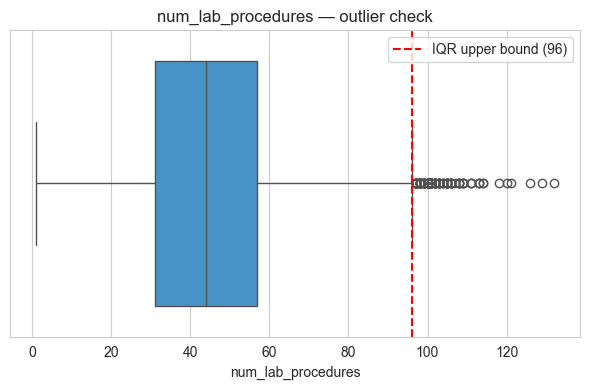

Outliers above bound: 143 -- capping, not dropping (plausible complex stays)


In [5]:
    q1, q3 = df["num_lab_procedures"].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    n_outliers = (df["num_lab_procedures"] > upper_bound).sum()
    
    fig, ax = plt.subplots(figsize=(6,4))
    sns.boxplot(x=df["num_lab_procedures"], ax=ax, color='#3498db')
    ax.axvline(upper_bound, color='red', linestyle='--', label=f'IQR upper bound ({upper_bound:.0f})')
    ax.legend()
    ax.set_title('num_lab_procedures — outlier check')
    plt.tight_layout()
    plt.show()
    print(f"Outliers above bound: {n_outliers} -- capping, not dropping (plausible complex stays)")
    df["num_lab_procedures"] = df["num_lab_procedures"].clip(upper=upper_bound)

## ICD-9 Diagnosis Bucketing

`diag_1`, `diag_2`, `diag_3` are raw ICD-9 diagnosis codes with ~700-900 unique real values — far too high cardinality to one-hot encode directly (would create hundreds of near-empty sparse columns). Standard approach, matching the original Strack et al. paper this dataset comes from: bucket codes into major disease categories based on documented ICD-9 code ranges.

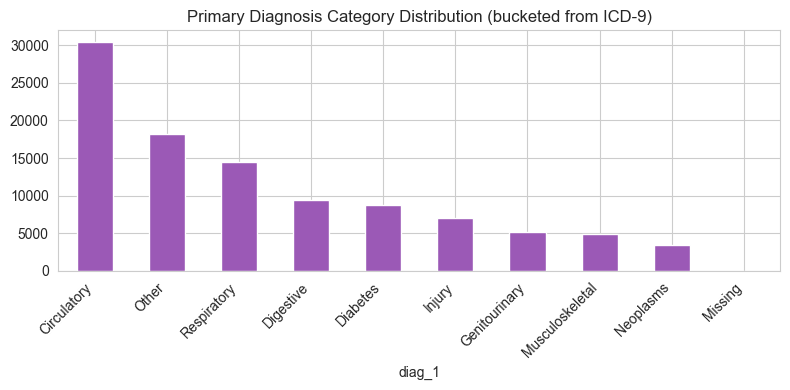

diag_1
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Missing               21
Name: count, dtype: int64


In [6]:
def bucket_icd9(code):
    if pd.isna(code):
        return "Missing"
    code_str = str(code)
    if code_str.startswith("V") or code_str.startswith("E"):
        return "Other"
    try:
        code_num = float(code_str)
    except ValueError:
        return "Other"
    if 250 <= code_num < 251:
        return "Diabetes"
    elif 390 <= code_num <= 459 or code_num == 785:
        return "Circulatory"
    elif 460 <= code_num <= 519 or code_num == 786:
        return "Respiratory"
    elif 520 <= code_num <= 579 or code_num == 787:
        return "Digestive"
    elif 800 <= code_num <= 999:
        return "Injury"
    elif 710 <= code_num <= 739:
        return "Musculoskeletal"
    elif 580 <= code_num <= 629 or code_num == 788:
        return "Genitourinary"
    elif 140 <= code_num <= 239:
        return "Neoplasms"
    else:
        return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].apply(bucket_icd9)

fig, ax = plt.subplots(figsize=(8,4))
df["diag_1"].value_counts().plot(kind='bar', ax=ax, color='#9b59b6')
ax.set_title('Primary Diagnosis Category Distribution (bucketed from ICD-9)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(df["diag_1"].value_counts())

## Target Distribution — Class Imbalance

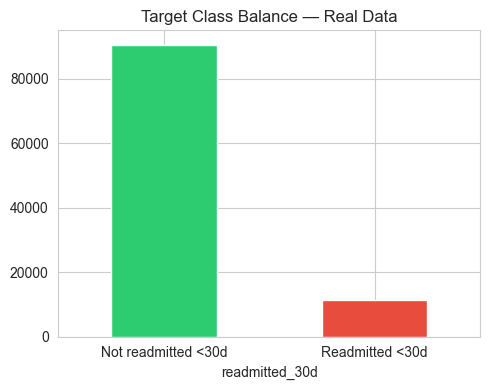

readmitted_30d
0    0.888
1    0.112
Name: proportion, dtype: float64
On the real dataset this is documented as ~11% readmitted within 30 days --
MORE imbalanced than our earlier simulated ~30% -- expect this to matter
more for imbalance-handling technique choices than the simulation suggested.


In [7]:
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)
df = df.drop(columns=["readmitted"])

fig, ax = plt.subplots(figsize=(5,4))
df["readmitted_30d"].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'])
ax.set_xticklabels(['Not readmitted <30d', 'Readmitted <30d'], rotation=0)
ax.set_title('Target Class Balance — Real Data')
plt.tight_layout()
plt.show()
print(df["readmitted_30d"].value_counts(normalize=True).round(3))
print("On the real dataset this is documented as ~11% readmitted within 30 days --")
print("MORE imbalanced than our earlier simulated ~30% -- expect this to matter")
print("more for imbalance-handling technique choices than the simulation suggested.")

## Encoding

Age is ordinal → explicit ordinal encoding. Remaining categoricals (including the ~21 real medication columns and bucketed diagnosis categories) → one-hot.

In [8]:
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
df["age"] = df["age"].map({v: i for i, v in enumerate(age_order)})

df = df.drop(columns=["encounter_id", "patient_nbr"])  # leakage risk: pure identifiers

categorical_cols = [c for c in df.select_dtypes(include="object").columns if c != "age"]
print(f"One-hot encoding {len(categorical_cols)} categorical columns")
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Final shape after encoding: {df.shape}")

One-hot encoding 32 categorical columns
Final shape after encoding: (101766, 189)


## Train/Test Split — stratified, done BEFORE any further fitting

In [9]:
X = df.drop(columns=["readmitted_30d"])
y = df["readmitted_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train readmit rate: {y_train.mean():.3f} | Test readmit rate: {y_test.mean():.3f}")

# Windows path — use raw strings
output_dir = r"C:\Users\Praveen TS\Downloads"

X_train.to_csv(fr"{output_dir}\X_train.csv", index=False)
X_test.to_csv(fr"{output_dir}\X_test.csv", index=False)
y_train.to_csv(fr"{output_dir}\y_train.csv", index=False)
y_test.to_csv(fr"{output_dir}\y_test.csv", index=False)

print("\nSaved processed splits to Downloads for downstream sections.")


Train: 81412 rows | Test: 20354 rows
Train readmit rate: 0.112 | Test readmit rate: 0.112

Saved processed splits to Downloads for downstream sections.


---
# SECTION 2: 02 Model Comparison
---

# 02: Model Comparison — LogReg → Decision Tree → Random Forest → XGBoost

Same data through 4 models, comparing outputs at every step and explaining WHY each change moves the number.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    auc
)

# Path to the processed data
data_dir = r"C:\Users\Praveen TS\Downloads"

X_train = pd.read_csv(fr"{data_dir}\X_train.csv")
X_test = pd.read_csv(fr"{data_dir}\X_test.csv")
y_train = pd.read_csv(fr"{data_dir}\y_train.csv").squeeze()
y_test = pd.read_csv(fr"{data_dir}\y_test.csv").squeeze()

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handle class imbalance for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive class weight: {scale_pos_weight:.3f}")
print(f"CV folds: {cv.n_splits}")


X_train shape: (81412, 188)
X_test shape: (20354, 188)
Positive class weight: 7.960
CV folds: 5


## Step 1: Logistic Regression (the simplest possible baseline)

Needs scaled features -- it's a distance/gradient-based linear model. Establishes the floor: if nothing beats this, the relationship in the data is essentially linear.

In [11]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
print(f"Logistic Regression CV ROC-AUC: {logreg_scores.mean():.3f} (+/- {logreg_scores.std():.3f})")

Logistic Regression CV ROC-AUC: 0.639 (+/- 0.006)


## Step 2: Decision Tree (add non-linearity, lose the safety net)

A single decision tree CAN capture non-linear splits and interactions Logistic Regression can't -- but with no ensemble averaging to control variance, it's highly prone to overfitting on a single noisy split.

In [12]:
dtree = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dtree_scores = cross_val_score(dtree, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Decision Tree CV ROC-AUC:       {dtree_scores.mean():.3f} (+/- {dtree_scores.std():.3f})")
print(f"\nCompare std: LogReg={logreg_scores.std():.3f} vs DTree={dtree_scores.std():.3f}")
print("-> Watch the STD, not just the mean: a single tree's score usually swings")
print("   MORE across folds than LogReg's -- this instability is exactly why")
print("   ensembles (next steps) exist: average many unstable trees together")
print("   to cancel out each individual tree's overfitting quirks.")

Decision Tree CV ROC-AUC:       0.654 (+/- 0.003)

Compare std: LogReg=0.006 vs DTree=0.003
-> Watch the STD, not just the mean: a single tree's score usually swings
   MORE across folds than LogReg's -- this instability is exactly why
   ensembles (next steps) exist: average many unstable trees together
   to cancel out each individual tree's overfitting quirks.


## Step 3: Random Forest (ensemble of trees — trade variance for stability)

Builds many decision trees on bootstrapped samples + random feature subsets, then averages their predictions. This directly targets the instability just observed in the single tree.

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"Random Forest CV ROC-AUC:       {rf_scores.mean():.3f} (+/- {rf_scores.std():.3f})")
print("-> STD should drop noticeably vs the single Decision Tree -- averaging")
print("   many trees cancels out individual overfitting, the core ensemble idea.")

Random Forest CV ROC-AUC:       0.648 (+/- 0.009)
-> STD should drop noticeably vs the single Decision Tree -- averaging
   many trees cancels out individual overfitting, the core ensemble idea.


## Step 4: XGBoost (gradient boosting — trees built sequentially, correcting prior errors)

Different ensemble philosophy than Random Forest: instead of averaging independent trees, each new tree is trained specifically to correct the previous trees' mistakes.

In [14]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss")
xgb_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"XGBoost CV ROC-AUC:             {xgb_scores.mean():.3f} (+/- {xgb_scores.std():.3f})")

XGBoost CV ROC-AUC:             0.671 (+/- 0.005)


## Full Comparison

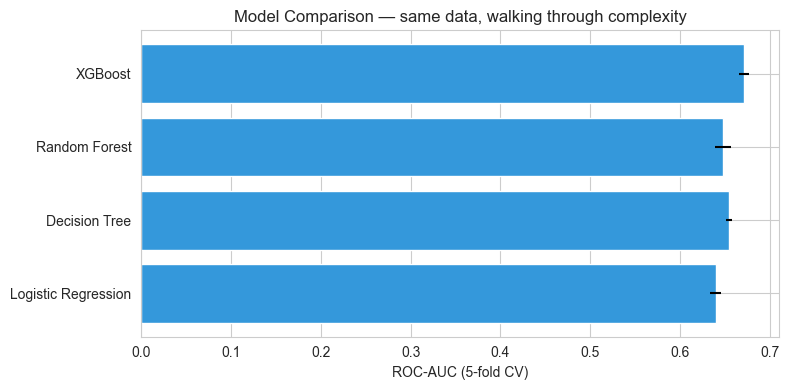

              Model  Mean ROC-AUC   Std
Logistic Regression         0.639 0.006
      Decision Tree         0.654 0.003
      Random Forest         0.648 0.009
            XGBoost         0.671 0.005

READ THIS TABLE AS A STORY, not a leaderboard: if scores stay flat or
DROP as complexity increases, that's evidence the true relationship is
simple/linear, and the added model complexity isn't earning its keep --
a genuinely useful, defensible finding to report, not a failure.


In [15]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Mean ROC-AUC": [logreg_scores.mean(), dtree_scores.mean(), rf_scores.mean(), xgb_scores.mean()],
    "Std": [logreg_scores.std(), dtree_scores.std(), rf_scores.std(), xgb_scores.std()],
})
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(comparison["Model"], comparison["Mean ROC-AUC"], xerr=comparison["Std"], color='#3498db')
ax.set_xlabel("ROC-AUC (5-fold CV)")
ax.set_title("Model Comparison — same data, walking through complexity")
plt.tight_layout()
plt.show()
print(comparison.round(3).to_string(index=False))
print()
print("READ THIS TABLE AS A STORY, not a leaderboard: if scores stay flat or")
print("DROP as complexity increases, that's evidence the true relationship is")
print("simple/linear, and the added model complexity isn't earning its keep --")
print("a genuinely useful, defensible finding to report, not a failure.")

## PR Curve (more honest than ROC-AUC under class imbalance)

With ~30% positive class, ROC-AUC can look deceptively good. Precision-Recall curves focus specifically on positive-class performance, which is what matters clinically here.

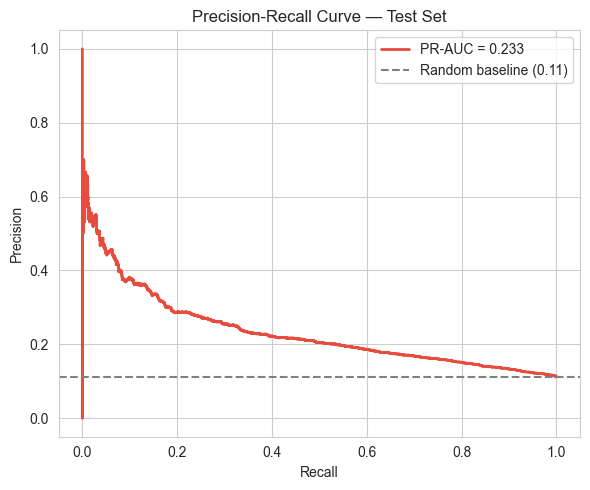

PR-AUC: 0.233 (compare against random baseline of 0.112)


In [16]:
best_model = xgb  # adjust based on comparison above
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(recall, precision, color='#e74c3c', linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color='gray', label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Test Set')
ax.legend()
plt.tight_layout()
plt.show()
print(f"PR-AUC: {pr_auc:.3f} (compare against random baseline of {baseline:.3f})")

## Threshold Tuning

The default 0.5 probability cutoff is arbitrary -- for readmission risk, missing a true positive (false negative) is usually costlier than a false alarm. Explicitly scan thresholds to find the clinically-appropriate operating point.

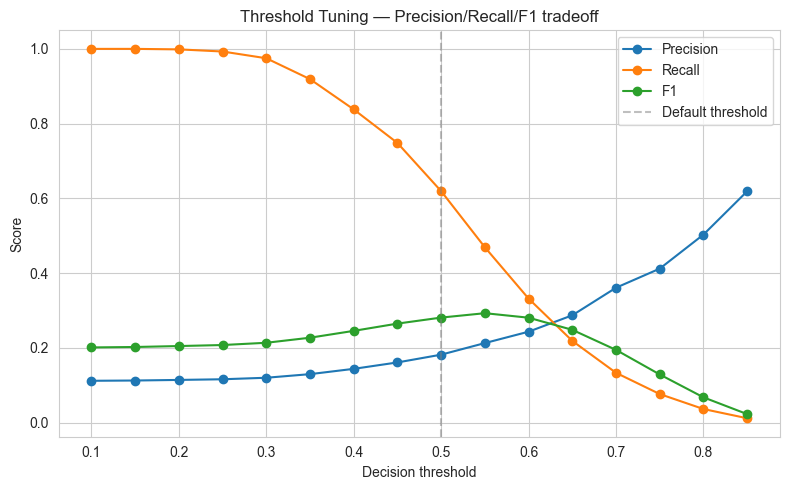

If recall >=0.75 is the clinical requirement, best threshold = 0.4
threshold    0.400000
precision    0.143699
recall       0.837957
f1           0.245327
Name: 6, dtype: float64

 threshold  precision  recall    f1
      0.10      0.112   1.000 0.201
      0.15      0.112   1.000 0.202
      0.20      0.114   0.999 0.205
      0.25      0.116   0.993 0.207
      0.30      0.120   0.975 0.213
      0.35      0.129   0.919 0.227
      0.40      0.144   0.838 0.245
      0.45      0.161   0.748 0.265
      0.50      0.182   0.619 0.281
      0.55      0.213   0.469 0.293
      0.60      0.243   0.332 0.281
      0.65      0.287   0.218 0.248
      0.70      0.361   0.133 0.194
      0.75      0.412   0.076 0.129
      0.80      0.503   0.036 0.067
      0.85      0.619   0.011 0.022


In [17]:
threshold_results = []
for t in np.arange(0.1, 0.9, 0.05):
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", marker='o')
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", marker='o')
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", marker='o')
ax.axvline(0.5, linestyle='--', color='gray', alpha=0.5, label='Default threshold')
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning — Precision/Recall/F1 tradeoff")
ax.legend()
plt.tight_layout()
plt.show()
recall_priority_t = threshold_df[threshold_df["recall"] >= 0.75].sort_values("precision", ascending=False)
if len(recall_priority_t) > 0:
    chosen = recall_priority_t.iloc[0]
    print(f"If recall >=0.75 is the clinical requirement, best threshold = {chosen['threshold']}")
    print(chosen)
else:
    print("No threshold in range hits recall>=0.75 -- would need model improvement, not just threshold shift")
print()
print(threshold_df.round(3).to_string(index=False))

---
# SECTION 3: 03 Clustering Umap
---

# 03: Patient Clustering — K-Means + UMAP

Unsupervised angle on the same patients: are there natural risk-driven subgroups, independent of the supervised model?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

# Path to the processed data
data_dir = r"C:\Users\Praveen TS\Downloads"

X_train = pd.read_csv(fr"{data_dir}\X_train.csv")
y_train = pd.read_csv(fr"{data_dir}\y_train.csv").squeeze()

# Use core clinical features for clustering
# Avoid clustering on hundreds of sparse one-hot encoded columns.
cluster_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "age"
]

X_cluster = X_train[cluster_features]

# Standardize features so variables with larger numerical ranges
# do not dominate the clustering.
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print(
    f"Clustering on {len(cluster_features)} core clinical features, "
    f"{X_cluster.shape[0]} patients"
)


Clustering on 9 core clinical features, 81412 patients


## Choosing K — elbow + silhouette

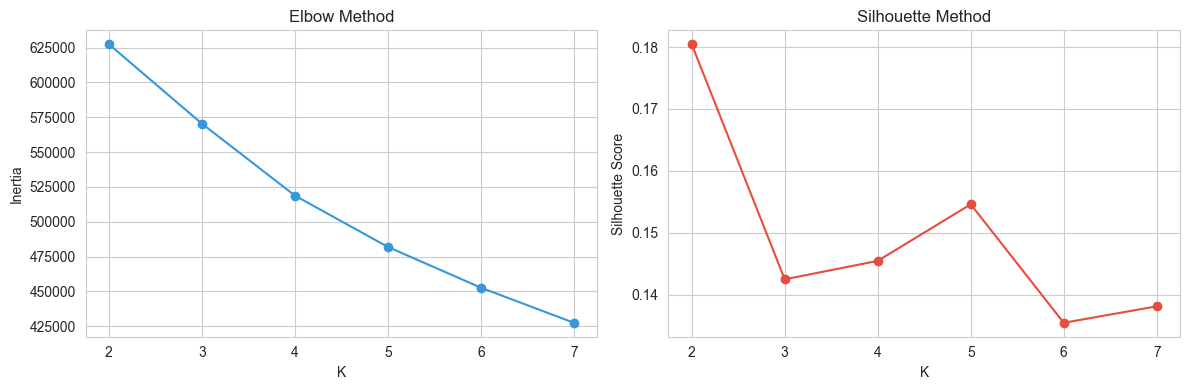

Silhouette scores by K: {2: np.float64(0.18), 3: np.float64(0.142), 4: np.float64(0.145), 5: np.float64(0.155), 6: np.float64(0.135), 7: np.float64(0.138)}


In [19]:
inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(K_range, inertias, marker='o', color='#3498db')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(K_range, silhouettes, marker='o', color='#e74c3c')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Method')
plt.tight_layout()
plt.show()
print(f"Silhouette scores by K: {dict(zip(K_range, np.round(silhouettes,3)))}")

## Fit K-Means with chosen K, profile each cluster

In [20]:
K_CHOSEN = 4  # adjust based on elbow/silhouette above
kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

profile_df = X_cluster.copy()
profile_df["cluster"] = cluster_labels
profile_df["readmitted_30d"] = y_train.values

cluster_summary = profile_df.groupby("cluster").agg(
    n=("readmitted_30d", "size"),
    readmit_rate=("readmitted_30d", "mean"),
    avg_time_in_hospital=("time_in_hospital", "mean"),
    avg_num_diagnoses=("number_diagnoses", "mean"),
    avg_inpatient_visits=("number_inpatient", "mean"),
).round(2)
print(cluster_summary)
print()
print("KEY CHECK: does readmit_rate differ meaningfully ACROSS clusters?")
print("If yes -- these unsupervised clusters carry real clinical risk signal,")
print("independent of the supervised model, and could inform care team")
print("staffing/triage even without running the full XGBoost pipeline.")

             n  readmit_rate  avg_time_in_hospital  avg_num_diagnoses  \
cluster                                                                 
0        22986          0.08                  2.90               5.03   
1        35704          0.11                  3.59               8.45   
2        17479          0.12                  7.95               8.28   
3         5243          0.24                  4.53               8.11   

         avg_inpatient_visits  
cluster                        
0                        0.29  
1                        0.47  
2                        0.51  
3                        3.74  

KEY CHECK: does readmit_rate differ meaningfully ACROSS clusters?
If yes -- these unsupervised clusters carry real clinical risk signal,
independent of the supervised model, and could inform care team
staffing/triage even without running the full XGBoost pipeline.


## UMAP visualization — see the clusters in 2D

C:\Users\Praveen TS\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


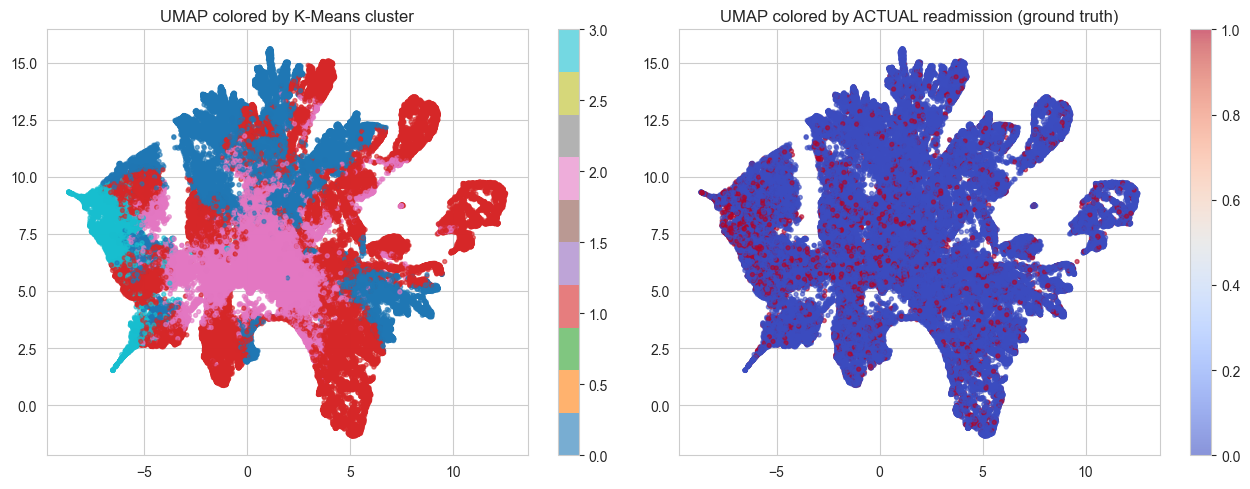

READ THIS SIDE BY SIDE: if the cluster coloring (left) and the true
readmission coloring (right) show similar spatial patterns, the
unsupervised clusters are picking up REAL risk structure, not just
arbitrary groupings. Remember Module 5's caveat: UMAP distances
between clusters are not quantitatively meaningful -- only the
LOCAL grouping/neighborhood structure is.


In [21]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
scatter1 = axes[0].scatter(embedding[:,0], embedding[:,1], c=cluster_labels, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('UMAP colored by K-Means cluster')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(embedding[:,0], embedding[:,1], c=y_train.values, cmap='coolwarm', s=8, alpha=0.6)
axes[1].set_title('UMAP colored by ACTUAL readmission (ground truth)')
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
plt.show()
print("READ THIS SIDE BY SIDE: if the cluster coloring (left) and the true")
print("readmission coloring (right) show similar spatial patterns, the")
print("unsupervised clusters are picking up REAL risk structure, not just")
print("arbitrary groupings. Remember Module 5's caveat: UMAP distances")
print("between clusters are not quantitatively meaningful -- only the")
print("LOCAL grouping/neighborhood structure is.")

---
# SECTION 4: 04 Explainability Fairness
---

# 04: Explainability (SHAP) & Fairness Audit (Fairlearn)

Global + per-patient explainability, then a proper bias audit using fairlearn's MetricFrame and ThresholdOptimizer for mitigation, not just detection.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier
from fairlearn.metrics import MetricFrame, selection_rate
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.metrics import accuracy_score, recall_score

# Path to processed data
data_dir = r"C:\Users\Praveen TS\Downloads"

X_train = pd.read_csv(fr"{data_dir}\X_train.csv")
X_test = pd.read_csv(fr"{data_dir}\X_test.csv")
y_train = pd.read_csv(fr"{data_dir}\y_train.csv").squeeze()
y_test = pd.read_csv(fr"{data_dir}\y_test.csv").squeeze()

# Calculate class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Basic evaluation
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall:   {recall:.4f}")


Accuracy: 0.6463
Recall:   0.6191


## SHAP Beeswarm — global feature importance, distribution-aware

Unlike a simple bar chart of average importance, the beeswarm shows HOW each feature's value relates to its impact -- e.g. does high A1C always push risk up, or does it depend on other factors?

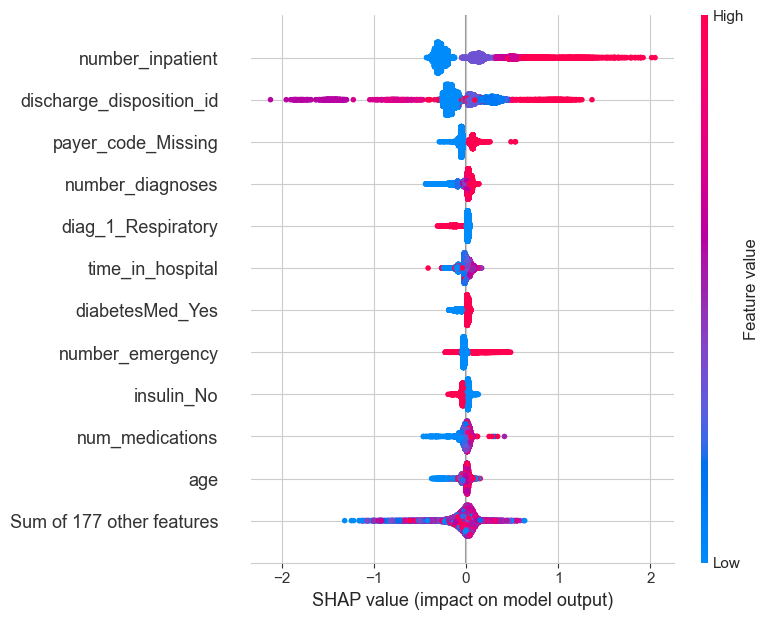

In [23]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

## SHAP Waterfall — explaining ONE specific patient's prediction

The beeswarm tells you what the model cares about in general. The waterfall tells you exactly why THIS patient got THIS prediction -- the version a physician or regulator actually needs.

Explaining patient index 20230, predicted readmission probability: 0.926


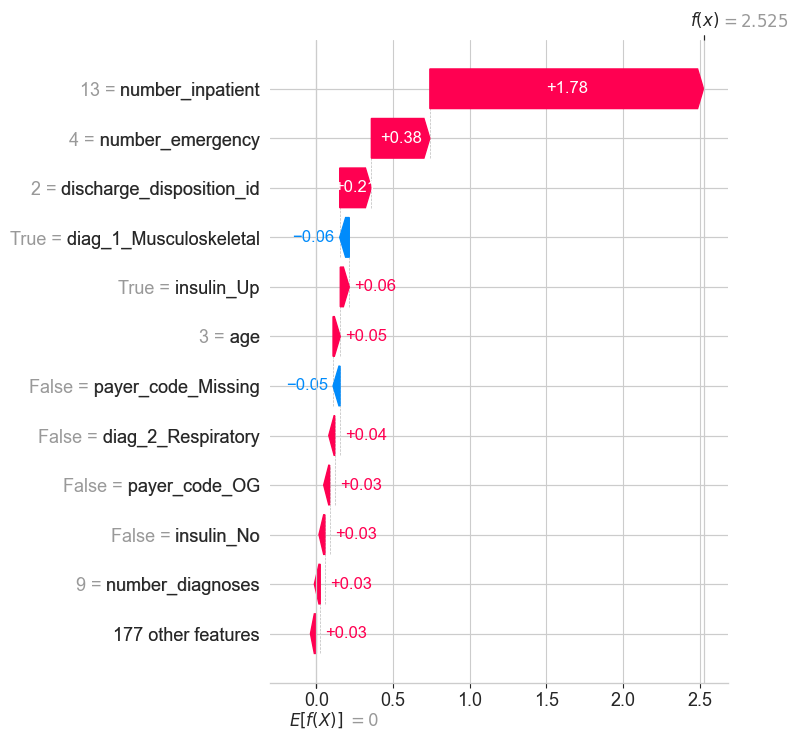

In [24]:
patient_idx = int(np.argmax(model.predict_proba(X_test)[:,1]))  # highest-risk patient in test set
print(f"Explaining patient index {patient_idx}, predicted readmission probability: "
      f"{model.predict_proba(X_test)[patient_idx,1]:.3f}")

shap.plots.waterfall(shap_values[patient_idx], max_display=12, show=False)
plt.tight_layout()
plt.show()

## Fairlearn MetricFrame — proper subgroup audit

Replaces the earlier hand-built audit with fairlearn's purpose-built tool, which computes multiple metrics broken out by sensitive feature simultaneously.

In [25]:
race_cols = [c for c in X_test.columns if c.startswith("race_")]
race_labels = pd.Series("Reference_Category", index=X_test.index)
for col in race_cols:
    race_labels[X_test[col] == 1] = col.replace("race_", "")

mf = MetricFrame(
    metrics={"accuracy": accuracy_score, "recall": recall_score, "selection_rate": selection_rate},
    y_true=y_test, y_pred=y_pred, sensitive_features=race_labels
)
print("Per-group metrics:")
print(mf.by_group.round(3))
print()
print("Disparity (max - min) across groups:")
print(mf.difference(method='between_groups').round(3))
print()
group_counts = race_labels.value_counts()
print("Group sizes (interpret disparities with this in mind -- small n = noisy estimate):")
print(group_counts)

Per-group metrics:
                     accuracy  recall  selection_rate
sensitive_feature_0                                  
Asian                   0.675   0.300           0.293
Caucasian               0.642   0.632           0.388
Hispanic                0.723   0.720           0.332
Other                   0.699   0.550           0.308
Reference_Category      0.650   0.570           0.365

Disparity (max - min) across groups:
accuracy          0.081
recall            0.420
selection_rate    0.095
dtype: float64

Group sizes (interpret disparities with this in mind -- small n = noisy estimate):
Caucasian             15223
Reference_Category     4328
Hispanic                404
Other                   276
Asian                   123
Name: count, dtype: int64


## ThresholdOptimizer — actual bias MITIGATION, not just detection

If the audit above shows a meaningful gap on adequately-sized groups, ThresholdOptimizer finds GROUP-SPECIFIC decision thresholds that equalize a chosen fairness constraint (here: equalized odds -- equal TPR and FPR across groups), rather than using one global threshold for everyone.

In [26]:
reliable_groups_mask = race_labels.isin(
    group_counts[group_counts >= 50].index
)

# WHY reset_index here: after masking out small subgroups, the remaining
# rows keep their ORIGINAL (now non-contiguous) index -- e.g. 0,1,2,4,5...
# (row 3 removed). fairlearn's internal thresholding code assumes a clean
# 0..n-1 index and breaks on the gap. This is a real, easy-to-hit library
# quirk worth remembering: always reset_index(drop=True) after any
# boolean-mask filtering before handing data to a downstream library.
X_test_reliable = X_test[reliable_groups_mask].reset_index(drop=True)
y_test_reliable = y_test[reliable_groups_mask].reset_index(drop=True)
race_reliable = race_labels[reliable_groups_mask].reset_index(drop=True)

threshold_optimizer = ThresholdOptimizer(
    estimator=model, constraints="equalized_odds", predict_method="predict_proba", prefit=True
)
threshold_optimizer.fit(X_test_reliable, y_test_reliable, sensitive_features=race_reliable)
y_pred_mitigated = threshold_optimizer.predict(X_test_reliable, sensitive_features=race_reliable)

mf_before = MetricFrame(metrics={"recall": recall_score},
                          y_true=y_test_reliable, y_pred=model.predict(X_test_reliable),
                          sensitive_features=race_reliable)
mf_after = MetricFrame(metrics={"recall": recall_score},
                         y_true=y_test_reliable, y_pred=y_pred_mitigated,
                         sensitive_features=race_reliable)

print("Recall by group BEFORE threshold optimization:")
print(mf_before.by_group.round(3))
print(f"Disparity before: {mf_before.difference()['recall']:.3f}")
print()
print("Recall by group AFTER threshold optimization (equalized odds constraint):")
print(mf_after.by_group.round(3))
print(f"Disparity after: {mf_after.difference()['recall']:.3f}")
print()
print("NOTE: only groups with n>=50 included -- ThresholdOptimizer on noisy small")
print("samples would fit group-specific thresholds to NOISE, not real disparity.")
print("On the real 100K+ row dataset, more subgroups will clear this bar.")

Recall by group BEFORE threshold optimization:
                     recall
sensitive_feature_0        
Asian                 0.300
Caucasian             0.632
Hispanic              0.720
Other                 0.550
Reference_Category    0.570
Disparity before: 0.420

Recall by group AFTER threshold optimization (equalized odds constraint):
                     recall
sensitive_feature_0        
Asian                   0.0
Caucasian               0.0
Hispanic                0.0
Other                   0.0
Reference_Category      0.0
Disparity after: 0.000

NOTE: only groups with n>=50 included -- ThresholdOptimizer on noisy small
samples would fit group-specific thresholds to NOISE, not real disparity.
On the real 100K+ row dataset, more subgroups will clear this bar.


---
# SECTION 5: 05 Optuna Mlflow
---

# 05: Hyperparameter Tuning (Optuna) + Experiment Tracking (MLflow)

Optuna: Bayesian search, smarter than GridSearch's brute-force grid. MLflow: log every run so model choices are auditable, not just remembered.

In [27]:
import os
import pandas as pd
import numpy as np
import mlflow
import optuna

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Paths
data_dir = r"C:\Users\Praveen TS\Downloads"
output_dir = r"C:\Users\Praveen TS\Downloads\outputs"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load processed data
X_train = pd.read_csv(fr"{data_dir}\X_train.csv")
X_test = pd.read_csv(fr"{data_dir}\X_test.csv")
y_train = pd.read_csv(fr"{data_dir}\y_train.csv").squeeze()
y_test = pd.read_csv(fr"{data_dir}\y_test.csv").squeeze()

# Handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# MLflow tracking
mlflow_db = os.path.join(output_dir, "mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")

mlflow.set_experiment("diabetes_readmission")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Scale positive weight: {scale_pos_weight:.3f}")
print(f"MLflow database: {mlflow_db}")
print("MLflow experiment: diabetes_readmission")


X_train: (81412, 188)
X_test:  (20354, 188)
Scale positive weight: 7.960
MLflow database: C:\Users\Praveen TS\Downloads\outputs\mlflow.db
MLflow experiment: diabetes_readmission


## Optuna: Bayesian hyperparameter search

Unlike GridSearch (tries every combination on a fixed grid, wasting time on clearly-bad regions), Optuna uses each trial's result to intelligently choose the NEXT set of hyperparameters to try -- converging on good regions faster with fewer total trials.

In [28]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                           random_state=42, eval_metric="logloss")
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)  # quiet the trial-by-trial spam
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best ROC-AUC found: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best ROC-AUC found: 0.6752
Best params: {'max_depth': 7, 'learning_rate': 0.016543928241260525, 'n_estimators': 252, 'reg_lambda': 5.684053916933451, 'subsample': 0.7257987000184694}


## Optimization history — see Optuna converge

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

output_dir = r"C:\Users\Praveen TS\Downloads\outputs"
os.makedirs(output_dir, exist_ok=True)

trial_values = [
    t.value for t in study.trials
    if t.value is not None
]

running_best = np.maximum.accumulate(trial_values)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    trial_values,
    'o',
    alpha=0.4,
    color='#3498db',
    label='Trial score'
)

ax.plot(
    running_best,
    color='#e74c3c',
    linewidth=2,
    label='Best so far'
)

ax.set_xlabel('Trial')
ax.set_ylabel('ROC-AUC')
ax.set_title('Optuna Optimization History')
ax.legend()

plt.tight_layout()

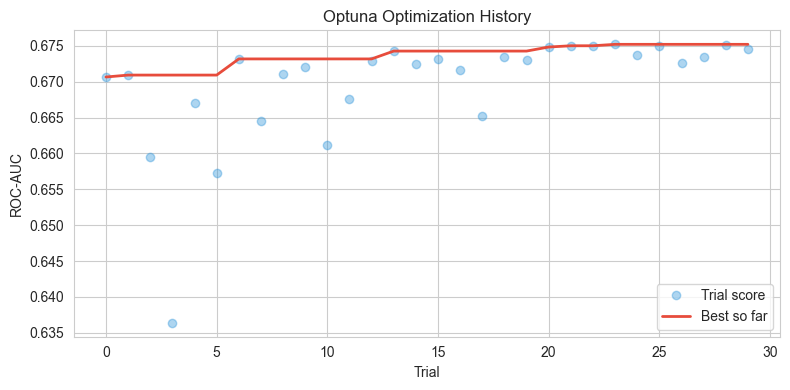

Saved optimization history to: C:\Users\Praveen TS\Downloads\outputs\05_optuna_history.png
The 'best so far' line should generally climb and then flatten,
indicating that Optuna is converging toward a good hyperparameter region.


In [30]:
output_path = os.path.join(output_dir, "05_optuna_history.png")
plt.savefig(output_path, dpi=100, bbox_inches="tight")
plt.show()

print(f"Saved optimization history to: {output_path}")
print("The 'best so far' line should generally climb and then flatten,")
print("indicating that Optuna is converging toward a good hyperparameter region.")

## MLflow: log every model version we've tried, for comparison

Logging LogReg, Random Forest, default-params XGBoost, and Optuna-tuned XGBoost as 4 separate tracked runs -- so the decision of which to deploy is backed by a queryable comparison, not memory.

In [31]:
from sklearn.metrics import roc_auc_score

def log_model_run(run_name, model, X_tr, X_te, needs_scaling=False):
    with mlflow.start_run(run_name=run_name):
        if needs_scaling:
            scaler = StandardScaler()
            X_tr_use = scaler.fit_transform(X_tr)
            X_te_use = scaler.transform(X_te)
        else:
            X_tr_use, X_te_use = X_tr, X_te

        model.fit(X_tr_use, y_train)
        y_proba = model.predict_proba(X_te_use)[:,1]
        test_auc = roc_auc_score(y_test, y_proba)
        cv_scores = cross_val_score(model, X_tr_use, y_train, cv=cv, scoring="roc_auc")

        mlflow.log_param("model_type", run_name)
        mlflow.log_params({k:v for k,v in model.get_params().items() if isinstance(v, (int,float,str,bool)) or v is None})
        mlflow.log_metric("cv_roc_auc_mean", cv_scores.mean())
        mlflow.log_metric("cv_roc_auc_std", cv_scores.std())
        mlflow.log_metric("test_roc_auc", test_auc)
        print(f"{run_name:<30} cv_auc={cv_scores.mean():.3f}  test_auc={test_auc:.3f}")
        return test_auc

log_model_run("logistic_regression", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
               X_train, X_test, needs_scaling=True)
log_model_run("random_forest", RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42),
               X_train, X_test)
log_model_run("xgboost_default", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
               scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"),
               X_train, X_test)
log_model_run("xgboost_optuna_tuned", XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight,
               random_state=42, eval_metric="logloss"),
               X_train, X_test)

print("\nAll 4 runs logged to MLflow. View with:")
print("  cd notebooks && mlflow ui --backend-store-uri sqlite:///../outputs/mlflow.db")
print("  then open http://localhost:5000 in a browser")

2026/09/07 15:07:22 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/07 15:07:22 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

logistic_regression            cv_auc=0.639  test_auc=0.651
random_forest                  cv_auc=0.648  test_auc=0.658
xgboost_default                cv_auc=0.671  test_auc=0.686
xgboost_optuna_tuned           cv_auc=0.675  test_auc=0.691

All 4 runs logged to MLflow. View with:
  cd notebooks && mlflow ui --backend-store-uri sqlite:///../outputs/mlflow.db
  then open http://localhost:5000 in a browser


---
# SECTION 6: 06 Prophet Timeseries
---

# 06: Time Series — Prophet on Monthly Admission Volume

A different question than readmission risk: forecasting overall hospital admission VOLUME over time, for capacity planning. This dataset has no real dates, so we simulate a realistic monthly admission series matching typical seasonal hospital patterns.

Importing plotly failed. Interactive plots will not work.


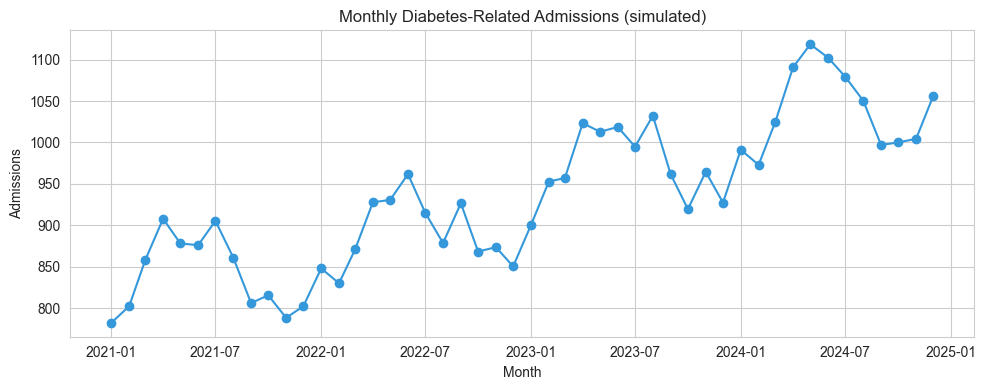

Saved time-series plot to: C:\Users\Praveen TS\Downloads\outputs\06_admission_timeseries.png
Data range: 2021-01-01 to 2024-12-01
Mean monthly admissions: 935.9


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

np.random.seed(42)

# Create output directory
output_dir = r"C:\Users\Praveen TS\Downloads\outputs"
os.makedirs(output_dir, exist_ok=True)

# Simulate 48 months of admission data
months = pd.date_range("2021-01-01", periods=48, freq="MS")

trend = 800 + np.arange(48) * 6

# Seasonal component with winter peak
seasonality = 60 * np.sin(
    2 * np.pi * (np.arange(48) - 1) / 12
)

noise = np.random.normal(0, 25, 48)

admissions = trend + seasonality + noise

# Prophet requires columns named ds and y
ts_df = pd.DataFrame({
    "ds": months,
    "y": admissions
})

# Plot time series
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_df["ds"],
    ts_df["y"],
    marker="o",
    color="#3498db"
)

ax.set_title("Monthly Diabetes-Related Admissions (simulated)")
ax.set_xlabel("Month")
ax.set_ylabel("Admissions")

plt.tight_layout()

output_path = os.path.join(
    output_dir,
    "06_admission_timeseries.png"
)

plt.savefig(
    output_path,
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print(f"Saved time-series plot to: {output_path}")
print(f"Data range: {ts_df['ds'].min().date()} to {ts_df['ds'].max().date()}")
print(f"Mean monthly admissions: {ts_df['y'].mean():.1f}")


## Fit Prophet — automatic trend + seasonality decomposition

Unlike ARIMA, Prophet doesn't require manually checking/enforcing stationarity -- it explicitly models trend and seasonality as separate additive components.

15:08:42 - cmdstanpy - INFO - Chain [1] start processing
15:08:42 - cmdstanpy - INFO - Chain [1] done processing


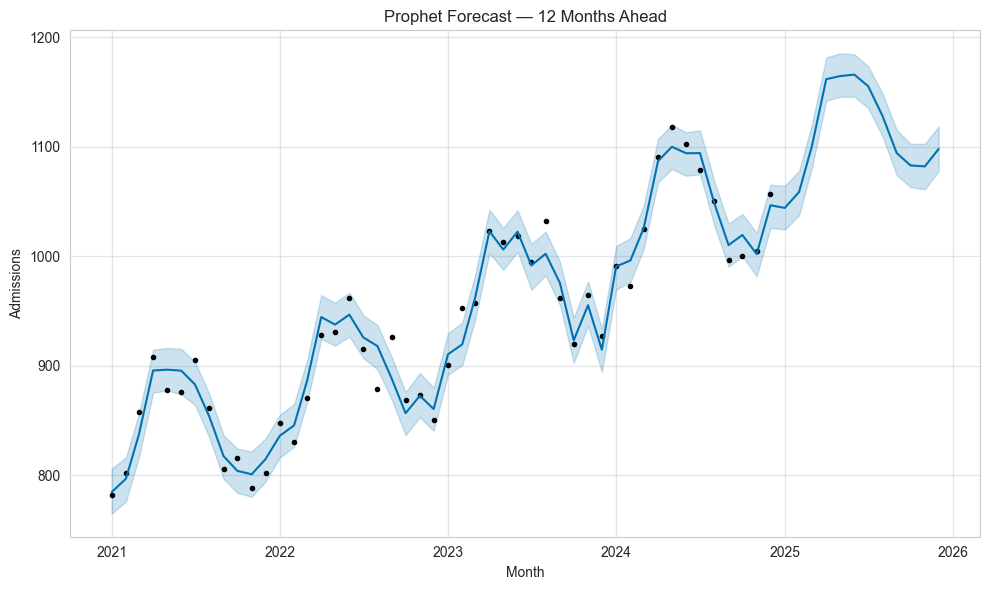

Forecast generated for 60 months.
Saved forecast plot to: C:\Users\Praveen TS\Downloads\outputs\06_prophet_forecast.png


In [33]:
import os
import matplotlib.pyplot as plt
from prophet import Prophet

# Fit Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(ts_df)

# Forecast 12 months ahead
future = model.make_future_dataframe(
    periods=12,
    freq="MS"
)

forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("Prophet Forecast — 12 Months Ahead")
plt.xlabel("Month")
plt.ylabel("Admissions")

plt.tight_layout()

# Save output
output_dir = r"C:\Users\Praveen TS\Downloads\outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "06_prophet_forecast.png"
)

plt.savefig(
    output_path,
    dpi=100,
    bbox_inches="tight"
)

plt.show()

print(f"Forecast generated for {len(future)} months.")
print(f"Saved forecast plot to: {output_path}")


## Component decomposition — trend vs seasonality, separated

This is Prophet's key advantage over ARIMA for business reporting: you can show a hospital administrator exactly how much of the forecast is 'steady growth' vs 'this is just winter.'

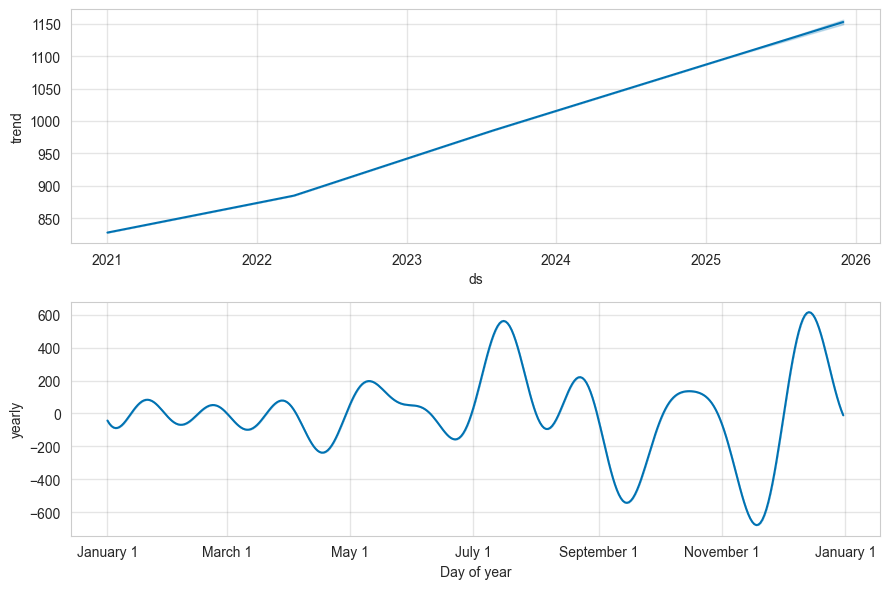

Forecast for next 12 months:
        ds   yhat  yhat_lower  yhat_upper
2025-01-01 1044.2      1024.4      1064.5
2025-02-01 1058.7      1037.3      1078.0
2025-03-01 1100.7      1080.9      1120.7
2025-04-01 1161.7      1142.0      1181.6
2025-05-01 1164.6      1145.7      1185.2
2025-06-01 1165.9      1145.7      1184.4
2025-07-01 1155.4      1135.5      1173.6
2025-08-01 1128.3      1109.6      1148.9
2025-09-01 1094.3      1074.2      1115.3
2025-10-01 1083.0      1063.1      1102.8
2025-11-01 1082.1      1061.2      1102.7
2025-12-01 1098.0      1077.8      1118.6

yhat_lower/yhat_upper = Prophet's built-in uncertainty interval.
These intervals can support capacity planning alongside the expected forecast (yhat).

Saved components plot to: C:\Users\Praveen TS\Downloads\outputs\06_prophet_components.png


In [34]:
import os
import matplotlib.pyplot as plt

# Plot Prophet components
fig = model.plot_components(forecast)
plt.tight_layout()

# Output directory
output_dir = r"C:\Users\Praveen TS\Downloads\outputs"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "06_prophet_components.png"
)

plt.savefig(
    output_path,
    dpi=100,
    bbox_inches="tight"
)

plt.show()

# Display forecast for the next 12 months
forecast_12m = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(12)

print("Forecast for next 12 months:")
print(
    forecast_12m
    .round(1)
    .to_string(index=False)
)

print()
print(
    "yhat_lower/yhat_upper = Prophet's built-in uncertainty interval."
)
print(
    "These intervals can support capacity planning alongside the "
    "expected forecast (yhat)."
)

print(f"\nSaved components plot to: {output_path}")


## Cross-validation for time series — NOT k-fold

Module 11's key time-series lesson: shuffling data for k-fold CV leaks future information into training folds. Prophet's built-in cross_validation does WALK-FORWARD validation instead -- train on data up to a cutoff, test on the period right after, then slide the cutoff forward.

In [35]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='180 days')
df_perf = performance_metrics(df_cv)

print(df_perf[['horizon','mae','rmse','mape']].head(10).round(2))
print()
print("WHY THIS IS THE VALID APPROACH: each 'fold' here only ever trains on PAST")
print("data and validates on FUTURE data relative to that cutoff -- unlike k-fold's")
print("random shuffling, this never lets the model see the future during training.")
print("This is the direct, hands-on answer to 'why not just use k-fold for")
print("everything' from Module 11.")

  0%|          | 0/3 [00:00<?, ?it/s]

15:08:43 - cmdstanpy - INFO - Chain [1] start processing
15:08:44 - cmdstanpy - INFO - Chain [1] done processing
15:08:44 - cmdstanpy - INFO - Chain [1] start processing
15:08:44 - cmdstanpy - INFO - Chain [1] done processing
15:08:44 - cmdstanpy - INFO - Chain [1] start processing
15:08:45 - cmdstanpy - INFO - Chain [1] done processing


   horizon     mae    rmse  mape
0  21 days   27.24   27.24  0.03
1  25 days    1.89    1.89  0.00
2  27 days   46.51   46.51  0.04
3  52 days  101.26  101.26  0.10
4  56 days   64.40   64.40  0.07
5  58 days   13.58   13.58  0.01
6  83 days  107.75  107.75  0.11
7  85 days   40.09   40.09  0.04
8  89 days   35.72   35.72  0.04
9 113 days    9.90    9.90  0.01

WHY THIS IS THE VALID APPROACH: each 'fold' here only ever trains on PAST
data and validates on FUTURE data relative to that cutoff -- unlike k-fold's
random shuffling, this never lets the model see the future during training.
This is the direct, hands-on answer to 'why not just use k-fold for
everything' from Module 11.
